In [8]:
import pandas as pd
import numpy as np
import os
import sys

In [9]:
gcn_mlp_results_df= pd.read_csv("GCN/TimedistributedMLP/gcn_mlp_results.csv")

In [10]:
metric = "spearman"


C:\Temp\ipykernel_45212\3951928848.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


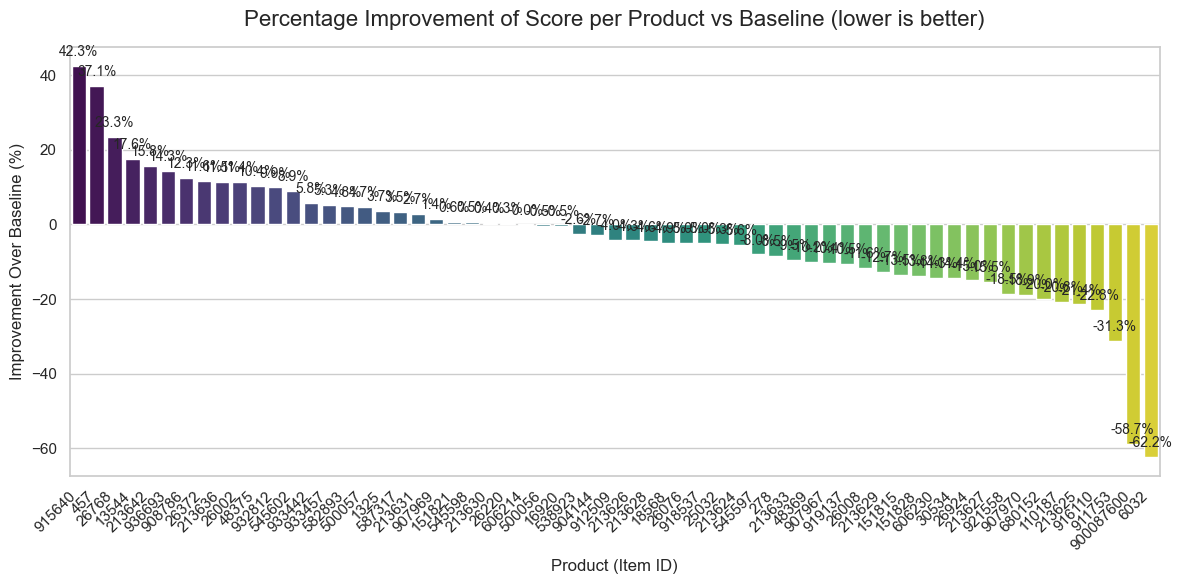

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

gcn_mlp_results_df['composite_score'] = gcn_mlp_results_df['r2_score']

# Baseline: the standalone baseline model (ablate_z == "baseline")
baseline_df = gcn_mlp_results_df[gcn_mlp_results_df['ablate_z'] == "baseline"].copy()
baseline_scores = baseline_df.groupby('item_id')['composite_score'].mean().reset_index()
baseline_scores.rename(columns={'composite_score': 'baseline_score'}, inplace=True)

ablation_df = gcn_mlp_results_df[gcn_mlp_results_df['ablate_z'] == "True"].copy()
ablation_scores = ablation_df.groupby('item_id')['composite_score'].mean().reset_index()
ablation_scores.rename(columns={'composite_score': 'ablation_score'}, inplace=True)
# Experimental: full GCN model (ablate_z == "False"), best (lowest) score per item
experimental_df = gcn_mlp_results_df[gcn_mlp_results_df['ablate_z'] == "False"].copy()
best_exp_scores = experimental_df.groupby('item_id')['composite_score'].min().reset_index()
best_exp_scores.rename(columns={'composite_score': 'best_experimental_score'}, inplace=True)

# Merge and calculate percentage improvement (lower is better)
# Positive % = experimental is lower (better) than baseline
improvement_df = pd.merge(baseline_scores, ablation_scores, on='item_id')
improvement_df = pd.merge(improvement_df, best_exp_scores, on='item_id')
improvement_df['pct_improvement'] = (
    (improvement_df[['baseline_score', 'ablation_score']].min(axis=1) - improvement_df['best_experimental_score'])
    / improvement_df[['baseline_score', 'ablation_score']].min(axis=1).abs()
) * 100

improvement_df = improvement_df.sort_values(by='pct_improvement', ascending=False)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=improvement_df,
    x='item_id',
    y='pct_improvement',
    palette='viridis',
    order=improvement_df['item_id']
)

plt.title('Percentage Improvement of Score per Product vs Baseline (lower is better)', fontsize=16, pad=15)
plt.xlabel('Product (Item ID)', fontsize=12)
plt.ylabel('Improvement Over Baseline (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.show()


In [15]:


styled_table = improvement_df.style.format({
    'baseline_score': '{:.4f}',
    'best_experimental_score': '{:.4f}',
    'pct_improvement': '{:+.2f}%'
}).background_gradient(
    subset=['pct_improvement'],
    cmap='RdYlGn',
    vmin=-10,
    vmax=10
).set_caption(
    "Percentage Improvement of Score per Product (GCN vs Baseline, lower is better)"
).set_table_styles([{
    'selector': 'caption',
    'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]
}]).hide(axis="index")

styled_table


item_id,baseline_score,ablation_score,best_experimental_score,pct_improvement
915640,10.8726,12.304495,6.2719,+42.31%
457,8.7053,7.445949,4.6822,+37.12%
26768,37.6166,22.955399,17.6035,+23.31%
13544,35.0356,30.601633,25.2178,+17.59%
213642,9.3363,8.701403,7.3302,+15.76%
936693,5.1484,5.335703,4.4114,+14.31%
908786,12.3139,12.461957,10.7973,+12.32%
26372,24.2706,22.539196,19.9190,+11.63%
213636,11.1107,7.661216,6.7815,+11.48%
26002,28.9986,33.302001,25.6899,+11.41%


In [13]:
import pandas as pd
from IPython.display import display

df = gcn_mlp_results_df.copy()
df['composite_score'] = df['r2_score']

# Baseline: the standalone baseline model (ablate_z == "baseline")
baseline = df[df['ablate_z'] == "baseline"].groupby('item_id')['composite_score'].min().reset_index()
baseline.rename(columns={'composite_score': 'Best_val_for_baseline'}, inplace=True)

# Experimental: full GCN model (ablate_z == "False"), pivot by threshold (min = best)
exp = df[df['ablate_z'] == "False"]
pivot_exp = pd.pivot_table(
    exp,
    values='composite_score',
    index='item_id',
    columns='threshold',
    aggfunc='min'
).reset_index()

# Merge
final_df = pd.merge(baseline, pivot_exp, on='item_id')

# Dynamically calculate relative performance vs baseline (lower is better)
# Positive % = threshold model is lower (better) than baseline
thresholds = [col for col in pivot_exp.columns if col != 'item_id']

ordered_cols = ['item_id', 'Best_val_for_baseline']
rel_cols_for_styling = []

for t in thresholds:
    val_col = f'Best_val_for_threshold_{t}'
    rel_col = f'Relative_Performance_for_threshold_{t}'

    final_df.rename(columns={t: val_col}, inplace=True)

    final_df[rel_col] = (
        (final_df['Best_val_for_baseline'] - final_df[val_col])
        / final_df['Best_val_for_baseline'].abs()
    ) * 100

    ordered_cols.extend([val_col, rel_col])
    rel_cols_for_styling.append(rel_col)

final_df = final_df[ordered_cols]

# Detailed table styling
format_dict = {col: '{:.4f}' for col in final_df.columns if col.startswith('Best_val')}
format_dict.update({col: '{:+.2f}%' for col in rel_cols_for_styling})

styled_table = final_df.style.format(format_dict).background_gradient(
    subset=rel_cols_for_styling,
    cmap='RdYlGn',
    vmin=-10,
    vmax=10
).set_caption(
    "Absolute Scores and Relative Performance per Threshold vs Baseline (lower is better)"
).set_table_styles([{
    'selector': 'caption',
    'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]
}, {
    'selector': 'th',
    'props': [('text-align', 'center'), ('background-color', '#f4f4f4')]
}]).hide(axis="index")

# Summary table
summary_data = []
mean_baseline = final_df['Best_val_for_baseline'].mean()

for t in thresholds:
    val_col = f'Best_val_for_threshold_{t}'
    rel_col = f'Relative_Performance_for_threshold_{t}'

    summary_data.append({
        'Threshold': t,
        'Mean Score': final_df[val_col].mean(),
        'Mean Improvement (%)': final_df[rel_col].mean(),
        'MAPE (%)': final_df[rel_col].abs().mean(),
        'Win Rate (%)': (final_df[rel_col] > 0).mean() * 100
    })

summary_df = pd.DataFrame(summary_data)

styled_summary = summary_df.style.format({
    'Mean Score': '{:.4f}',
    'Mean Improvement (%)': '{:+.2f}%',
    'MAPE (%)': '{:.2f}%',
    'Win Rate (%)': '{:.1f}%'
}).background_gradient(
    subset=['Mean Improvement (%)', 'Win Rate (%)'],
    cmap='RdYlGn',
    vmin=-2,
    vmax=2
).set_caption(
    f"Average Performance Metrics by Threshold (Baseline Avg Score: {mean_baseline:.4f})"
).set_table_styles([{
    'selector': 'caption',
    'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px'), ('color', '#333')]
}, {
    'selector': 'th',
    'props': [('text-align', 'center'), ('background-color', '#e8f4f8')]
}]).hide(axis="index")

display(styled_table)
display(styled_summary)


item_id,Best_val_for_baseline,Best_val_for_threshold_0.75,Relative_Performance_for_threshold_0.75,Best_val_for_threshold_0.78,Relative_Performance_for_threshold_0.78,Best_val_for_threshold_0.82,Relative_Performance_for_threshold_0.82,Best_val_for_threshold_0.85,Relative_Performance_for_threshold_0.85,Best_val_for_threshold_0.88,Relative_Performance_for_threshold_0.88
110187,33.8406,39.1778,-15.77%,39.1147,-15.59%,42.3027,-25.01%,42.7550,-26.34%,44.2067,-30.63%
1325,5.9576,6.0462,-1.49%,6.2040,-4.14%,5.7361,+3.72%,7.1597,-20.18%,8.6899,-45.86%
13544,35.0356,25.3010,+27.78%,25.2178,+28.02%,31.6938,+9.54%,28.0092,+20.06%,31.1913,+10.97%
151815,12.2118,10.7285,+12.15%,15.9472,-30.59%,23.4853,-92.32%,12.8340,-5.10%,13.5083,-10.62%
151821,9.5099,13.5108,-42.07%,12.2538,-28.85%,9.4550,+0.58%,12.2918,-29.25%,10.9113,-14.74%
151828,7.0704,8.1320,-15.02%,8.6431,-22.24%,7.9978,-13.12%,7.8082,-10.44%,9.0150,-27.50%
16920,7.1884,7.2241,-0.50%,8.6269,-20.01%,7.7463,-7.76%,7.7702,-8.09%,7.5069,-4.43%
18568,17.3438,18.2023,-4.95%,18.8765,-8.84%,19.3994,-11.85%,19.0771,-9.99%,19.4731,-12.28%
213624,7.7091,8.9456,-16.04%,9.4076,-22.03%,9.1835,-19.13%,12.5369,-62.62%,8.1417,-5.61%
213625,8.0286,12.3598,-53.95%,12.8033,-59.47%,9.9374,-23.78%,9.7493,-21.43%,10.6309,-32.41%


Threshold,Mean Score,Mean Improvement (%),MAPE (%),Win Rate (%)
0.750000,13.7347,-12.47%,20.71%,31.1%
0.780000,13.7664,-13.36%,19.39%,27.9%
0.820000,14.2017,-13.62%,20.55%,27.9%
0.850000,14.3007,-15.58%,23.22%,24.6%
0.880000,14.8488,-19.90%,25.90%,19.7%
